In [1]:
from scipy.cluster.hierarchy import ward, average, fcluster, dendrogram
from scipy.spatial.distance import pdist, squareform
from scipy import sparse
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
X = [[0, 0], [0, 1], [1, 0],
     [0, 4], [0, 3], [1, 4],
     [4, 0], [3, 0], [4, 1],
     [4, 4], [3, 4], [4, 3]]
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
X.shape

(150, 4)

In [ ]:
# Dataset: maybe subset out all the genes with <1 observation (i.e., no distribution could be created)

(150, 4)

In [3]:
# Get distance matrix
dist = pdist(X)
dist_matrix = sparse.csc_matrix(squareform(dist)) # Shape: no. cells (init_conds) x no. cells
# Zsquare = squareform(Z) which one is faster?

In [4]:
# Average linkage clustering (also done in paper)
Z = average(dist)
# Column 0 and 1 contain cluster indices merged in that row
# Column 2 contains the height of the new cluster
# Column 3 contains the size of the new cluster

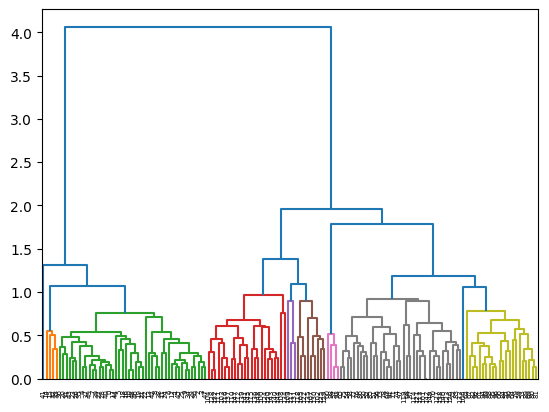

In [5]:
dendrogram(Z,color_threshold=1)
plt.show()

In [6]:
# Get all possible clusterings (N x N matrix)
clusterings = np.empty((0,dist_matrix.shape[0]),int)
heights = np.unique(np.round(Z[:,2]-1e-5,decimals=5)) # 1e-5 means
for height in heights:
    clustering = fcluster(Z,t=height,criterion="distance")
    clusterings = np.append(clusterings,[clustering],axis=0)
if len(np.unique(clusterings[0])) == dist_matrix.shape[0]:
    heights = heights[1:]
    clusterings = clusterings[1:]
if len(np.unique(clusterings[-1])) == 1:
    heights = heights[:-1]
    clusterings = clusterings[:-1]

In [8]:
len(clusterings)

110

149
144
129
127
126
122
121
119
118
114
113
112
111
110
108
107
102
101
100
99
98
97
96
90
89
88
87
86
85
84
83
82
81
80
79
78
77
76
74
73
72
70
69
68
67
66
65
64
63
62
61
60
59
58
57
56
55
54
53
52
51
50
49
48
47
46
45
44
43
42
41
40
39
38
37
36
35
34
33
32
31
30
29
28
27
26
25
24
23
22
21
20
19
18
17
16
15
14
13
12
11
10
9
8
7
6
5
4
3
2


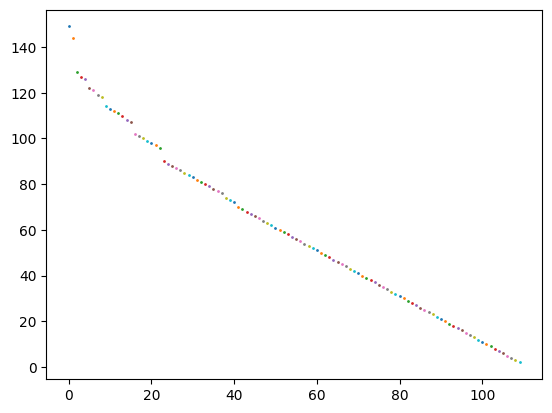

In [9]:
for i in range(clusterings.shape[0]):

    plt.scatter(i,len(np.unique(clusterings[i,:])),s=1)
    print(len(np.unique(clusterings[i,:])))
plt.show()

In [10]:
# Calculate the silhouette scores:
sil_scores = []
for i in range(clusterings.shape[0]):
    
    sil_scores.append(silhouette_score(dist_matrix,clusterings[i]))

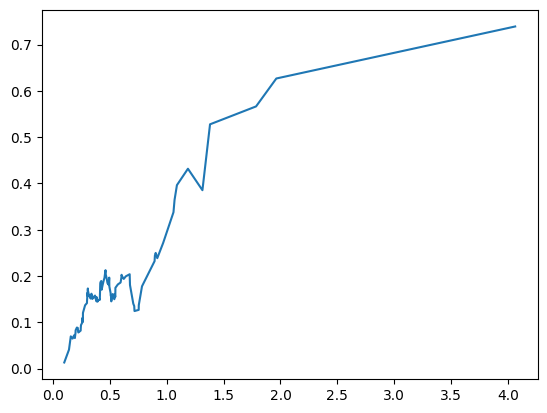

In [11]:
plt.plot(heights,sil_scores)
plt.show()

In [12]:
# Get the best clusterings
top_sils = 10
best_clusterings = clusterings[np.argsort(sil_scores)[::-1][:top_sils],:][:3]

In [13]:
# Get the cluster that is the closest to the control mean in some way:
adata_mean = np.mean(X,axis=0)
for clustering in best_clusterings:
    clusters = np.unique(clustering)
    print(clusters)
    # Get mean gene vector for each cluster
    cluster_mean = np.asarray([np.mean(X[clustering == cluster],axis=0) for cluster in sorted(np.unique(clustering))])
    # Among the clusters in the current clustering, get the one with the best metric
    print(cluster_mean)
    metric = cosine_similarity(cluster_mean,[adata_mean]).T
    print(metric)
    best_cluster = clusters[np.argmax(metric)] # Maybe Pearson Delta?
    print(best_cluster)

[1 2]
[[5.006 3.428 1.462 0.246]
 [6.262 2.872 4.906 1.676]]
[[0.94844663 0.99338934]]
2
[1 2 3]
[[5.006      3.428      1.462      0.246     ]
 [6.85277778 3.075      5.78611111 2.09722222]
 [5.9296875  2.7578125  4.4109375  1.4390625 ]]
[[0.94844663 0.98770839 0.9961897 ]]
3
[1 2 3 4]
[[5.006      3.428      1.462      0.246     ]
 [6.85277778 3.075      5.78611111 2.09722222]
 [5.         2.3        3.275      1.025     ]
 [5.99166667 2.78833333 4.48666667 1.46666667]]
[[0.94844663 0.98770839 0.99888156 0.99594588]]
3
